# Hungry Agent — Natural-Language Goals Meet Cost-Driven Planning

A Tier 1 primer that combines two of LangGOAP's headline features
in a tiny, readable domain:

1. **`GoalInterpreter`** — turns a natural-language request like
   `"I'm tired and hungry, figure it out"` into a structured
   `GoalSpec`.
2. **Cost-weighted A***  — picks the cheapest combination of
   actions that satisfies the interpreted goal, adapting to
   whatever happens to be in the world state.

## Domain

The agent is hungry and tired.  Four actions are available:

| Action           | Preconditions          | Cost |
|------------------|------------------------|------|
| `eat_snack`      | `has_snack=True`       | 1.0  |
| `cook_meal`      | `has_ingredients=True` | 3.0  |
| `order_delivery` | *(none)*               | 5.0  |
| `sleep`          | *(none)*               | 1.0  |

The same English request (`"I'm tired and hungry..."`) produces
different plans depending on what the agent has on hand.  The planner
reads the world state, not the intent.

## Mocking the LLM

This notebook uses `FakeStructuredModel` — the same test helper used
by LangGOAP's own integration suite — so it runs offline without API
keys.  In production you would swap in `ChatOpenAI`, `ChatAnthropic`,
or any other `BaseChatModel`.  The rest of the code is identical.

In [ ]:
from tutorial_examples.hungry_agent import (
    hungry_agent_actions,
    hungry_agent_start,
)

from langgoap import GoalInterpreter, GoapGraph, InterpretedGoal, successful_action_names
from langgoap.testing import FakeStructuredModel

# In production: from langchain_openai import ChatOpenAI; llm = ChatOpenAI(model="gpt-4o")
llm = FakeStructuredModel(
    response=InterpretedGoal(
        conditions={"hungry": False, "tired": False},
        reasoning="User is tired and hungry; needs to eat and rest.",
    ),
)

### GOAP Execution Graph

The planner discovers a plan, the executor runs each action, and the
observer checks progress — replanning automatically if something fails.

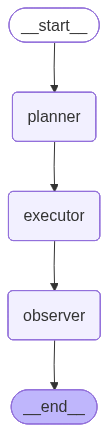

In [2]:
from IPython.display import Image, display

graph = GoapGraph(actions=hungry_agent_actions())
display(Image(graph.compile().get_graph().draw_mermaid_png()))

## 1. Snack on hand — cheapest path wins

With a snack available, `eat_snack` (cost 1) dominates the other
food actions.  The planner pairs it with `sleep` (cost 1) for a
total plan cost of **2.0**.

Note that we never mention `hungry` or `tired` as boolean keys in the
call — `GoalInterpreter` extracts them from the English request.

In [ ]:
actions = hungry_agent_actions()
state = hungry_agent_start(has_snack=True, has_ingredients=True)

graph = GoapGraph(actions=actions)
result = graph.invoke_nl(
    "I'm tired and hungry, figure it out",
    llm=llm,
    world_state=state,
)

successful = successful_action_names(result)
print(f"Status:     {result['status']}")
print(f"Plan:       {' + '.join(sorted(successful))}")
print(f"Final:      hungry={result['world_state']['hungry']}, tired={result['world_state']['tired']}")

## 2. No snack, but ingredients are available

Remove the snack and A* falls back to the next-cheapest eating
action: `cook_meal` (cost 3).  Total plan cost rises to **4.0**,
but the English request hasn't changed at all.

In [ ]:
state = hungry_agent_start(has_snack=False, has_ingredients=True)

result = graph.invoke_nl(
    "I'm tired and hungry, figure it out",
    llm=llm,
    world_state=state,
)

successful = successful_action_names(result)
print(f"Plan:       {' + '.join(sorted(successful))}")

## 3. Empty kitchen — delivery is the only option

With neither a snack nor ingredients, A* has to reach for the most
expensive action: `order_delivery` (cost 5).  Total plan cost **6.0**.

This is the core value proposition of goal-oriented planning — one
request, three different plans, zero code changes.

In [ ]:
state = hungry_agent_start(has_snack=False, has_ingredients=False)

result = graph.invoke_nl(
    "I'm tired and hungry, figure it out",
    llm=llm,
    world_state=state,
)

successful = successful_action_names(result)
print(f"Plan:       {' + '.join(sorted(successful))}")

## 4. Inspecting the interpreted goal

`GoalInterpreter.interpret_raw()` returns the full `InterpretedGoal`
— the structured object the LLM emitted, including the reasoning
trace.  This is invaluable for debugging prompt behavior in
production.

In [6]:
interpreter = GoalInterpreter(llm=llm, actions=actions)
raw = interpreter.interpret_raw("I'm tired and hungry, figure it out")

print(f"Conditions: {dict(raw.conditions)}")
print(f"Reasoning:  {raw.reasoning}")

Conditions: {'hungry': False, 'tired': False}
Reasoning:  User is tired and hungry; needs to eat and rest.


## 5. Visualizing the winning plan

`Plan.to_ascii()` renders the plan as a tree showing step order and
dependencies.  `eat_snack` and `sleep` have no data dependency on
each other, so they appear as independent roots — either one could
run first (or in parallel, if the executor supports it).

In [7]:
from langgoap import GoalSpec
from langgoap.planner.astar import plan as astar_plan
from langgoap.state import PlanningState

plan_obj = astar_plan(
    PlanningState.from_dict(hungry_agent_start(has_snack=True, has_ingredients=True)),
    GoalSpec(conditions={"hungry": False, "tired": False}),
    actions,
)
print(plan_obj.to_ascii())
print(f"Total cost: {plan_obj.total_cost}")

Plan (2 steps, cost=2)
├── [0] eat_snack
├── [1] sleep

Total cost: 2.0


## Summary

- **One NL request, three plans.** `GoalInterpreter` turns English
  into a `GoalSpec`; A* picks the cheapest actions for the current
  world state.
- **The LLM is provider-agnostic.** Any `BaseChatModel` works —
  `FakeStructuredModel` here, `ChatOpenAI` / `ChatAnthropic` in
  production.
- **The planner adapts, not the prompt.** Same request produces
  `eat_snack + sleep` (cost 2), `cook_meal + sleep` (cost 4), or
  `order_delivery + sleep` (cost 6) depending on the starting state.

Every scenario here is verified by
[`tests/integration/test_hungry_agent.py`](../../tests/integration/test_hungry_agent.py).